#**Punto 1 – Python**

En este punto se realizó un proceso completo de análisis y transformación de una imagen RGB de un animal en vía de extinción utilizando Python y OpenCV. Primero se cargó y visualizó la imagen original, la cual sirvió como referencia para evaluar los cambios producidos por los filtros y operaciones posteriores. Luego se aplicó un filtro de suavizado para reducir ruido y un filtro de realce de bordes para resaltar contornos importantes.

Posteriormente, la imagen fue separada en sus tres canales de color (R, G y B), lo que permitió analizar qué información visual aporta cada uno y cómo varían intensidades en distintas zonas de la imagen. Finalmente, se aplicaron dos operaciones morfológicas (erosión y dilatación) sobre una versión binarizada, mostrando cómo estas transformaciones adelgazan o expanden las estructuras presentes.

Se generó un GIF que muestra de forma secuencial la imagen original, los filtros aplicados y los resultados de las operaciones morfológicas, lo cual facilita visualizar el proceso completo de transformación paso a paso.

In [15]:
# ============================
# 0. IMPORTAR LIBRERIAS
# ============================

from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import imageio
import os

##**1. Carga y visualización**

En esta sección cargamos una imagen RGB de un animal en vía de extinción. Visualizar la imagen original nos permite tener un punto de referencia para evaluar los efectos de los filtros y transformaciones posteriores.

Sube una imagen RGB de un animal en vía de extinción


Saving Foto-7-Condor-macho_optimized.jpg to Foto-7-Condor-macho_optimized.jpg


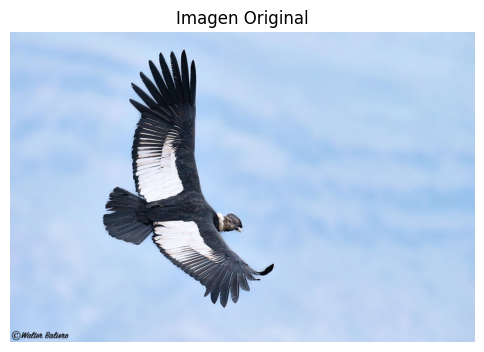

In [16]:
# -----------------------------------------
# 1. CARGA DE IMAGEN
# -----------------------------------------
print("Sube una imagen RGB de un animal en vía de extinción")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.title("Imagen Original")
plt.imshow(img)
plt.axis("off")
plt.show()


##**2. Filtros básicos**

Aplicamos dos filtros:

Suavizado / Blur: Reduce el ruido y hace que los bordes luzcan más suaves.

Realce de bordes: Destaca contornos importantes y resalta la estructura del objeto.

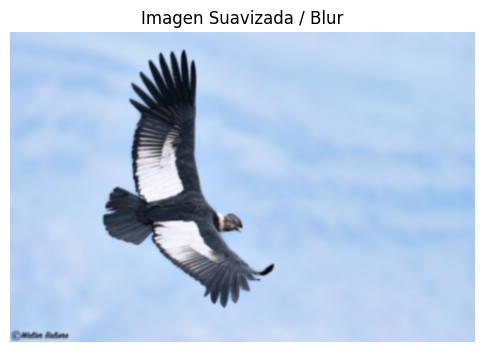

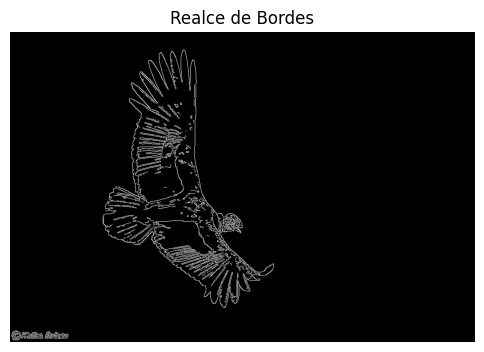

In [17]:

# -----------------------------------------
# 2. FILTROS BÁSICOS
# -----------------------------------------

# Filtro suavizado
blur = cv2.GaussianBlur(img, (9,9), 0)

plt.figure(figsize=(6,6))
plt.title("Imagen Suavizada / Blur")
plt.imshow(blur)
plt.axis("off")
plt.show()

# Filtro de bordes Canny
edges = cv2.Canny(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), 100, 200)

plt.figure(figsize=(6,6))
plt.title("Realce de Bordes")
plt.imshow(edges, cmap='gray')
plt.axis("off")
plt.show()

##**3. Visualización de canales RGB**

Al separar los canales de color podemos observar qué información aporta cada uno.
Algunas zonas se ven más claras u oscuras según qué canal tenga mayor intensidad en esa región.

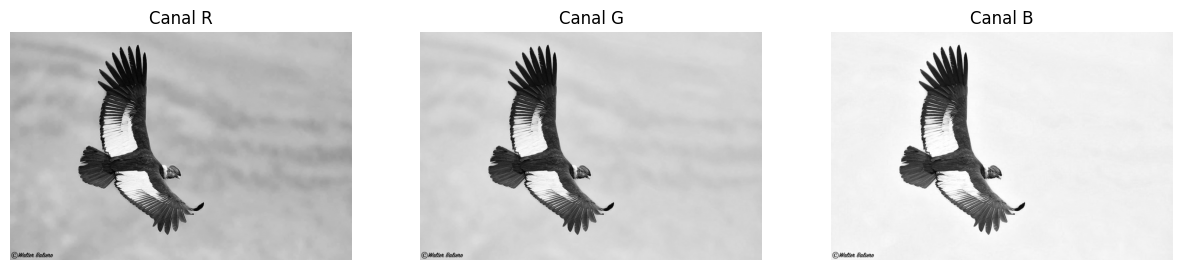

In [18]:
# -----------------------------------------
# 3. CANALES RGB
# -----------------------------------------
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(R, cmap="gray"); ax[0].set_title("Canal R")
ax[1].imshow(G, cmap="gray"); ax[1].set_title("Canal G")
ax[2].imshow(B, cmap="gray"); ax[2].set_title("Canal B")
for a in ax: a.axis("off")
plt.show()

#**4. Operaciones morfológicas**

Usamos versiones binarias o en escala de grises:

Erosión: adelgaza estructuras y elimina detalles pequeños.

Dilation: expande estructuras, cierra espacios y hace que los objetos se vean más gruesos.

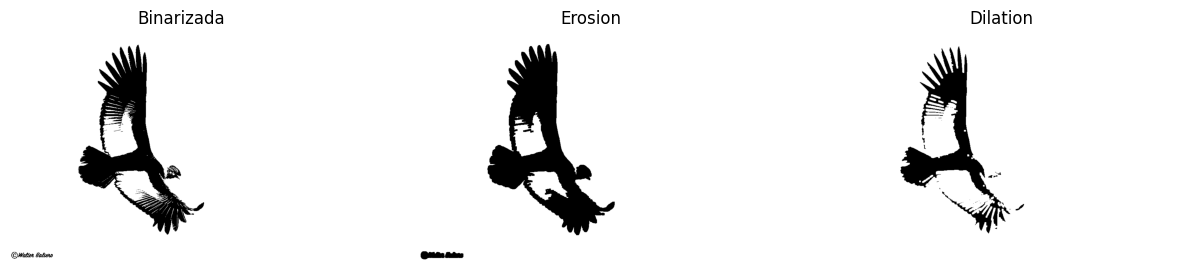

In [19]:

# -----------------------------------------
# 4. OPERACIONES MORFOLÓGICAS
# -----------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)

erosion = cv2.erode(thresh, kernel, iterations=1)
dilation = cv2.dilate(thresh, kernel, iterations=1)

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(thresh, cmap="gray"); ax[0].set_title("Binarizada")
ax[1].imshow(erosion, cmap="gray"); ax[1].set_title("Erosion")
ax[2].imshow(dilation, cmap="gray"); ax[2].set_title("Dilation")
for a in ax: a.axis("off")
plt.show()


##**5. Animación (GIF)**

Para visualizar de manera dinámica cada una de las transformaciones aplicadas a la imagen, se generaron dos GIFs independientes. El primer GIF corresponde a los filtros básicos, mostrando cómo la imagen pasa de su estado original al suavizado y posteriormente al realce de bordes. Esto permite observar de forma clara cómo cada filtro modifica la textura y los contornos del animal.

El segundo GIF corresponde a las operaciones morfológicas, aplicadas sobre la versión binarizada de la imagen. En él se puede ver la transición desde la binarización hacia la erosión y finalmente la dilatación. Estas animaciones permiten comparar fácilmente los efectos que tienen las operaciones morfológicas sobre las estructuras presentes en la imagen, ya que reducen, eliminan o expanden detalles según el tipo de operación.

Ambos GIFs se muestran directamente y se guardan.

GIF 1 generado en: gifs/filtros.gif


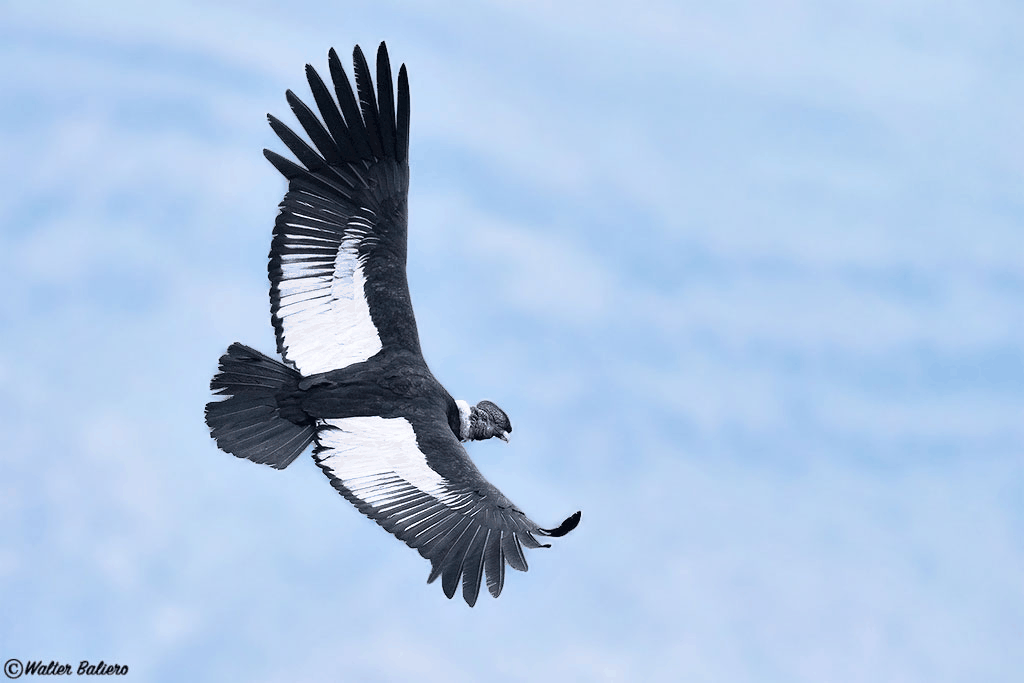

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# -----------------------------------------
# 5. ANIMACIONES (GIFs)
# -----------------------------------------
from IPython.display import Image as ColabImage

os.makedirs("gifs", exist_ok=True)

# -------------------------
# GIF 1 - Filtros básicos
# -------------------------
frames_filters = [
    img,
    blur,
    cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB),
]

gif_filters_path = "gifs/filtros.gif"
imageio.mimsave(gif_filters_path, frames_filters, duration=0.8)

print("GIF 1 generado en:", gif_filters_path)

# Mostrar GIF en el notebook
display(ColabImage(gif_filters_path))

# Descargar
files.download(gif_filters_path)





GIF 2 generado en: gifs/morfologia.gif


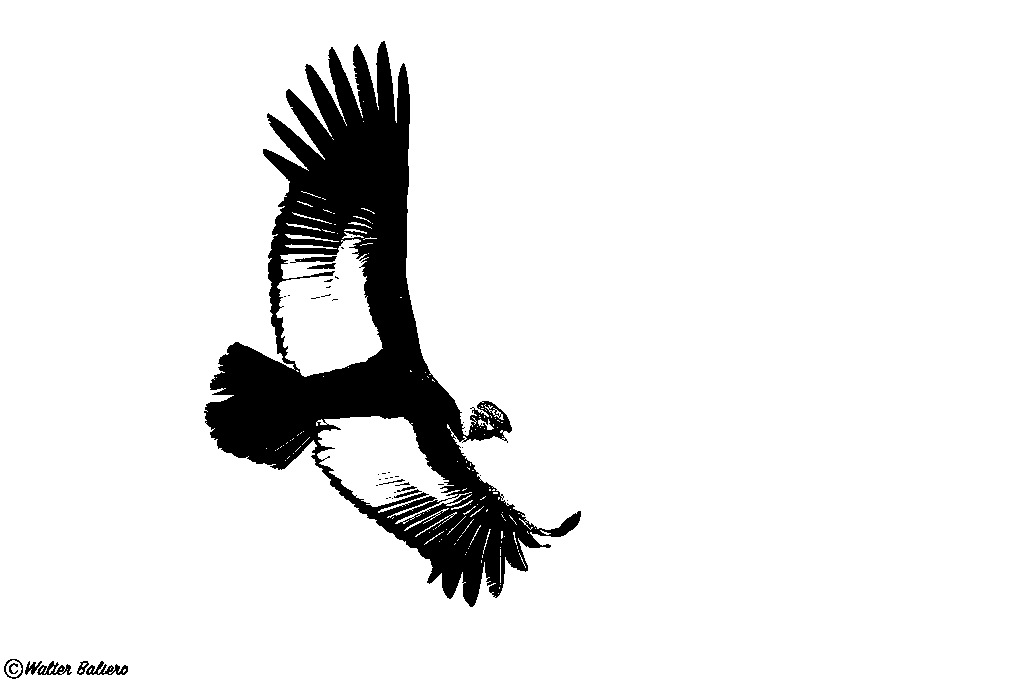

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# -------------------------------
# GIF 2 - Operaciones morfológicas
# -------------------------------
frames_morph = [
    cv2.cvtColor(thresh, cv2.COLOR_GRAY2RGB),
    cv2.cvtColor(erosion, cv2.COLOR_GRAY2RGB),
    cv2.cvtColor(dilation, cv2.COLOR_GRAY2RGB),
]

gif_morph_path = "gifs/morfologia.gif"
imageio.mimsave(gif_morph_path, frames_morph, duration=0.8)

print("GIF 2 generado en:", gif_morph_path)

# Mostrar en notebook
display(ColabImage(gif_morph_path))

# Descargar
files.download(gif_morph_path)